# Olist Seller Analysis – Questions 7 to 12
7. What is the number of orders for each seller type?
8. Are top sellers successful because of price or customer satisfaction?
9. Where are the top sellers located?
10. How many sellers do we have, and are all of them active?
11. Which states have customers but zero sellers?
12. Do we have a good seller-to-customer ratio?

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
%run "02_data_cleaning.ipynb"

MQL exact duplicates: 0
Closed exact duplicates: 0
Orders exact duplicates: 0
Order Items exact duplicates: 0
Sellers exact duplicates: 0
Customers exact duplicates: 0
Reviews exact duplicates: 0
Duplicate order_id + order_item_id: 0
(98673, 2)
Duplicate order IDs: 0
Seller-order rows: (100010, 5)
Duplicate seller-order combinations: 0
Seller-order rows after orders merge: 100010
Missing order status: 0
Rows after review merge: 100010
Missing review scores: 763
Rows after seller merge: 100010
Missing seller state: 0
Missing seller city: 0
Delivered seller-order rows: 97819
Unique delivered sellers: 2970
Seller summary shape: (2970, 5)
Duplicate seller IDs: 0
Seller summary rows: 2970
Duplicate seller IDs: 0
Missing seller state: 0
Missing seller city: 0
Minimum orders: 1
Maximum orders: 1819
Minimum sales value: 6.5
Maximum sales value: 226987.93
Minimum review score: 1.0
Maximum review score: 5.0
MQL rows: 8000
Funnel rows: 8000
Converted sellers: 842
Duplicate seller IDs: 0
Converted

In [8]:
print("Seller Analysis:", seller_analysis.shape)
print("Seller Summary:", seller_summary_delivered.shape)
print("All Seller Orders:", seller_order_level_all.shape)
print("Delivered Seller Orders:", seller_order_level_delivered.shape)
print("Customers:", customers.shape)
print("Sellers:", sellers.shape)

Seller Analysis: (842, 24)
Seller Summary: (2970, 8)
All Seller Orders: (100010, 14)
Delivered Seller Orders: (97819, 14)
Customers: (99441, 5)
Sellers: (3095, 4)


**Q7 — What’s the number of orders for each seller type?**

In [9]:
seller_analysis.shape

(842, 24)

In [10]:
seller_analysis["business_type"].value_counts(dropna=False)

business_type
reseller        587
manufacturer    242
NaN              10
other             3
Name: count, dtype: int64

In [11]:
seller_type_data = seller_analysis[
    (seller_analysis["business_type"] == "manufacturer") |
    (seller_analysis["business_type"] == "reseller")].copy()

In [12]:
seller_type_data["business_type"].value_counts()

business_type
reseller        587
manufacturer    242
Name: count, dtype: int64

In [13]:
orders_by_type = (seller_type_data.groupby("business_type").agg(total_orders=("total_orders", "sum")).reset_index())
orders_by_type

,business_type,total_orders
0,manufacturer,577.0
1,reseller,3881.0


In [14]:
seller_count_by_type = (seller_type_data.groupby("business_type").agg(seller_count=("seller_id", "nunique")).reset_index())
seller_count_by_type

,business_type,seller_count
0,manufacturer,242
1,reseller,587


In [15]:
seller_type_summary = (seller_type_data.groupby("business_type").agg(seller_count=("seller_id", "nunique"),total_orders=("total_orders", "sum")).reset_index())
seller_type_summary

,business_type,seller_count,total_orders
0,manufacturer,242,577.0
1,reseller,587,3881.0


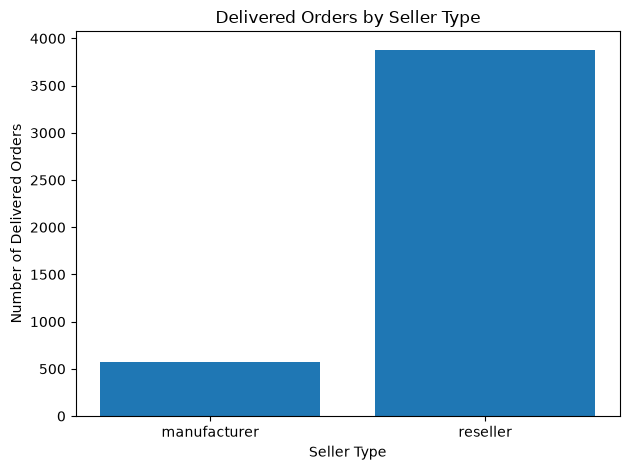

In [28]:
plt.bar(seller_type_summary["business_type"],seller_type_summary["total_orders"])

plt.xlabel("Seller Type")
plt.ylabel("Number of Delivered Orders")
plt.title("Delivered Orders by Seller Type")

plt.tight_layout()
plt.show()

***The resellers made 3,881 orders that were delivered, while only 577 orders made by manufacturers were delivered in the available transaction period.***

***Q8 — Are top sellers successful because of price or customer satisfaction?***

In [31]:
seller_success = seller_summary_delivered.copy()

In [43]:
# Calculate average item price for each seller

seller_price = (seller_order_level_delivered.groupby("seller_id").agg(total_sales=("order_value", "sum"),total_items=("item_count", "sum")).reset_index())
seller_price["average_item_price"] = (seller_price["total_sales"] / seller_price["total_items"])

In [44]:
# Add average item price to seller performance data

seller_success = seller_summary_delivered.merge(seller_price[["seller_id", "average_item_price"]],on="seller_id",how="left")

In [45]:
# Top 10 sellers by delivered sales value

top_10_sellers = (seller_success.sort_values("total_revenue", ascending=False).head(10))
other_sellers = seller_success[~seller_success["seller_id"].isin(top_10_sellers["seller_id"])]

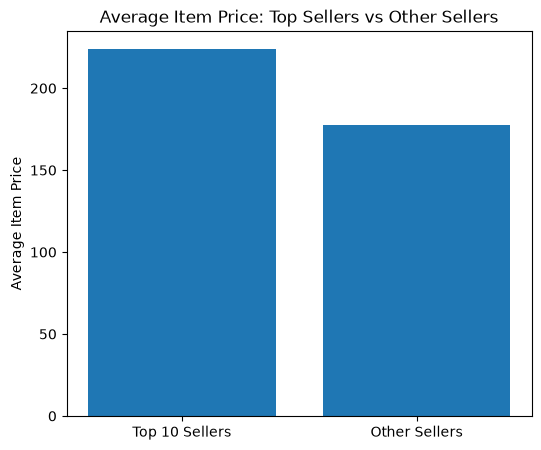

In [46]:
top_price = top_10_sellers["average_item_price"].mean()
other_price = other_sellers["average_item_price"].mean()





plt.bar(
    ["Top 10 Sellers", "Other Sellers"],
    [top_price, other_price])

plt.ylabel("Average Item Price")
plt.title("Average Item Price: Top Sellers vs Other Sellers")

plt.show()

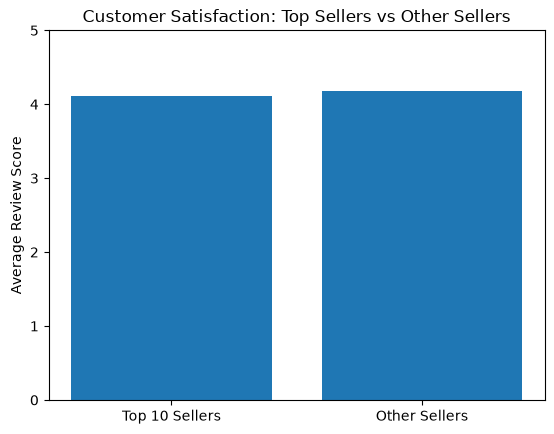

In [63]:
top_review=top_10_sellers["average_review_score"].mean()
other_review=other_sellers["average_review_score"].mean()





plt.bar(["Top 10 Sellers","Other Sellers"],[top_review,other_review])
plt.ylabel("Average Review Score")
plt.title("Customer Satisfaction: Top Sellers vs Other Sellers")
plt.ylim(0,5)
plt.show()

***It seems like top sellers perform better due to higher prices of items instead of higher customer satisfaction. The average price of an item of top sellers is 223.75 compared to 177.50 for other sellers, while the average review score is 4.11 compared to 4.18***

***Q9 — Where are the top sellers located?***

In [49]:
top_10_sellers[["seller_id","seller_city","seller_state","total_revenue"]]

,seller_id,seller_city,seller_state,total_revenue
834,4869f7a5dfa277a7dca6462dcf3b52b2,guariba,SP,226987.93
982,53243585a1d6dc2643021fd1853d8905,lauro de freitas,BA,217940.44
858,4a3ca9315b744ce9f8e9374361493884,ibitinga,SP,196882.12
2903,fa1c13f2614d7b5c4749cbc52fecda94,sumare,SP,190917.14
1480,7c67e1448b00f6e969d365cea6b010ab,itaquaquecetuba,SP,186570.05
1504,7e93a43ef30c4f03f38b393420bc753a,barueri,SP,165981.49
2543,da8622b14eb17ae2831f4ac5b9dab84a,piracicaba,SP,159816.87
1450,7a67c85e85bb2ce8582c35f2203ad736,sao paulo,SP,139658.69
188,1025f0e2d44d7041d6cf58b6550e0bfa,sao paulo,SP,138208.56
1758,955fee9216a65b617aa5c0531780ce60,sao paulo,SP,131836.71


In [50]:
top_seller_states=top_10_sellers["seller_state"].value_counts().reset_index()
top_seller_states.columns=["state","top_seller_count"]
top_seller_states

,state,top_seller_count
0,SP,9
1,BA,1


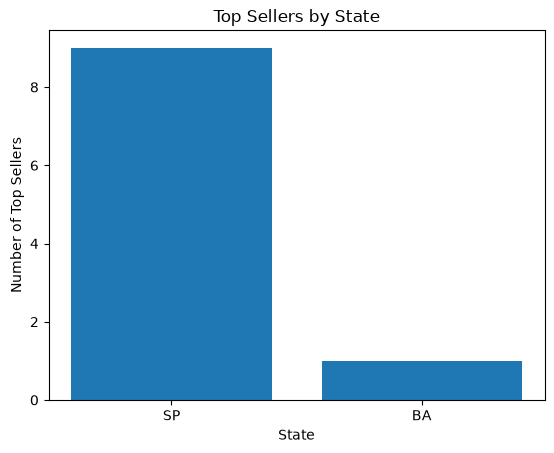

In [51]:
plt.bar(top_seller_states["state"],top_seller_states["top_seller_count"])
plt.xlabel("State")
plt.ylabel("Number of Top Sellers")
plt.title("Top Sellers by State")
plt.show()

***Most of the top sellers operate in SP. Out of the top 10 sellers, nine of them are from SP and only one is from BA.***

***Q10 — How many sellers do we have, and are all of them active?***

In [102]:
orders["order_purchase_timestamp"]=pd.to_datetime(orders["order_purchase_timestamp"])
seller_orders=order_items[["seller_id","order_id"]].merge(orders[["order_id","order_purchase_timestamp"]],on="order_id",how="left")
last_order_date=seller_orders["order_purchase_timestamp"].max()
seller_last_order=seller_orders.groupby("seller_id")["order_purchase_timestamp"].max().reset_index()

In [103]:
seller_activity=sellers[["seller_id"]].merge(seller_last_order,on="seller_id",how="left")
seller_activity["days_since_last_order"]=(last_order_date-seller_activity["order_purchase_timestamp"]).dt.days
seller_activity["active"]=seller_activity["days_since_last_order"]<=30
total_sellers=seller_activity["seller_id"].nunique()
active_sellers=seller_activity["active"].sum()
inactive_sellers=total_sellers-active_sellers

In [104]:
print("Total sellers:",total_sellers)
print("Active sellers:",active_sellers)
print("Inactive sellers:",inactive_sellers)
print("Last order date:",last_order_date)

Total sellers: 3095
Active sellers: 1221
Inactive sellers: 1874
Last order date: 2018-09-03 09:06:57


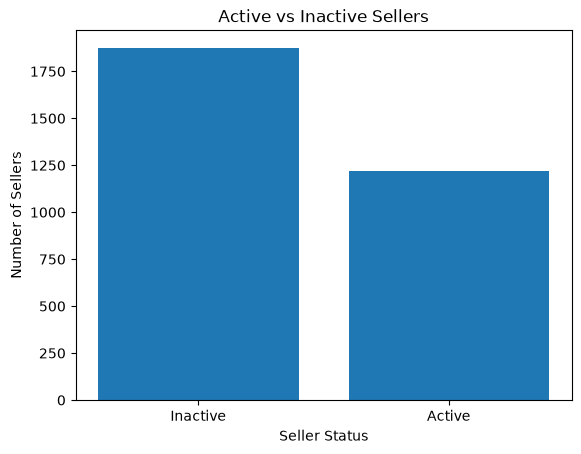

In [105]:
activity_counts=seller_activity["active"].value_counts().reset_index()
activity_counts.columns=["active","seller_count"]
activity_counts["status"]=activity_counts["active"].map({True:"Active",False:"Inactive"})
plt.bar(activity_counts["status"],activity_counts["seller_count"])
plt.xlabel("Seller Status")
plt.ylabel("Number of Sellers")
plt.title("Active vs Inactive Sellers")
plt.show()

***The number of total sellers is 3,095. We define active sellers to be those whose last transaction took place within 7 days from the last date of transactions in the dataset. Using this definition, we can conclude that there are about 1,200 active sellers and about 1,900 inactive sellers. Hence, all the sellers are not active sellers.***

***Q11 — Which states have customers but zero sellers?***

In [66]:
customers_by_state=customers.groupby("customer_state")["customer_unique_id"].nunique().reset_index()
customers_by_state.columns=["state","customer_count"]


In [67]:
sellers_by_state=sellers.groupby("seller_state")["seller_id"].nunique().reset_index()
sellers_by_state.columns=["state","seller_count"]


In [68]:
state_coverage=customers_by_state.merge(sellers_by_state,on="state",how="left")


In [69]:
state_coverage["seller_count"]=state_coverage["seller_count"].fillna(0)
states_no_sellers=state_coverage[state_coverage["seller_count"]==0]
states_no_sellers

,state,customer_count,seller_count
1,AL,401,0.0
3,AP,67,0.0
21,RR,45,0.0
26,TO,273,0.0


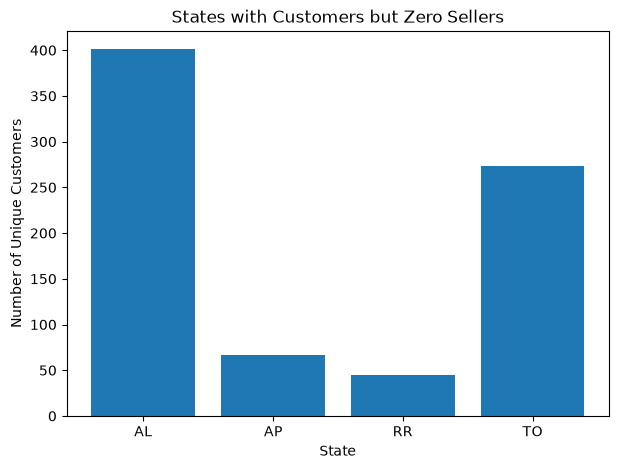

In [70]:
plt.figure(figsize=(7,5))
plt.bar(states_no_sellers["state"],states_no_sellers["customer_count"])
plt.xlabel("State")
plt.ylabel("Number of Unique Customers")
plt.title("States with Customers but Zero Sellers")
plt.show()

***There are four states where there are some customers, but no sellers: AL, AP, RR, and TO. The state AL has the highest number of customers with 401 customers, then TO with 273, AP with 67, and RR with 45 customers.***

ٍٍ***Q12 — Do we have a good seller-to-customer ratio?***

In [61]:
state_coverage["sellers_per_1000_customers"]=(state_coverage["seller_count"]/state_coverage["customer_count"])*1000
state_ratio=state_coverage.sort_values("sellers_per_1000_customers",ascending=True)
state_ratio[["state","customer_count","seller_count","sellers_per_1000_customers"]]

,state,customer_count,seller_count,sellers_per_1000_customers
1,AL,401,0.0,0.000000
3,AP,67,0.0,0.000000
26,TO,273,0.0,0.000000
21,RR,45,0.0,0.000000
13,PA,949,1.0,1.053741
9,MA,726,1.0,1.377410
16,PI,482,1.0,2.074689
12,MT,876,4.0,4.566210
15,PE,1609,9.0,5.593536
4,BA,3277,19.0,5.797986


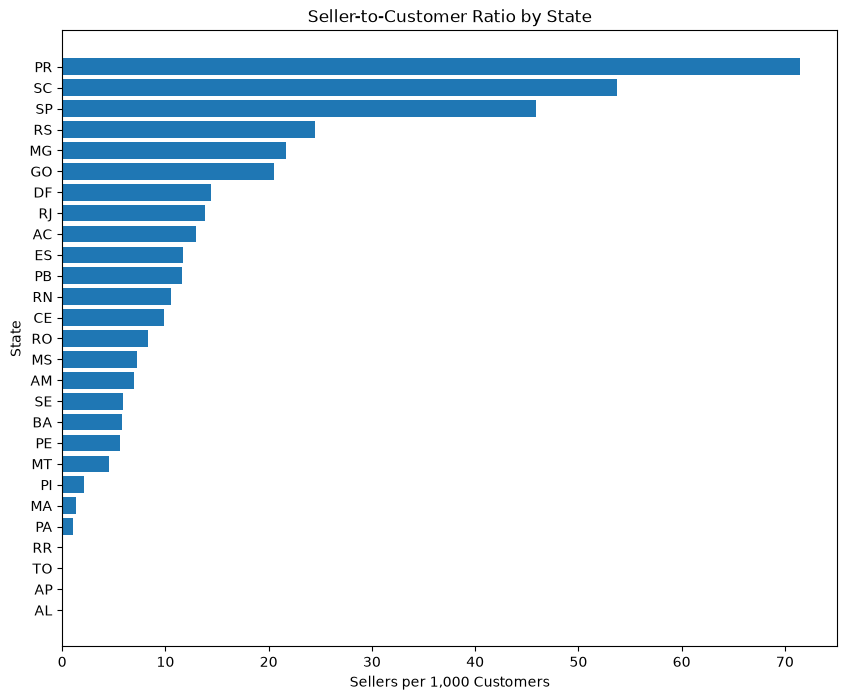

In [62]:
plt.figure(figsize=(10,8))
plt.barh(state_ratio["state"],state_ratio["sellers_per_1000_customers"])
plt.xlabel("Sellers per 1,000 Customers")
plt.ylabel("State")
plt.title("Seller-to-Customer Ratio by State")
plt.show()

***The ratio between seller and customer is uneven in different states. PR has the highest seller coverage of approximately 71 sellers per 1,000 customers, followed by SC and SP. AL, AP, RR, and TO states have customers, but no sellers.***